In [2]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sns.set_theme(style="whitegrid")

In [4]:
temperature = np.array([
    66, 70, 69, 68, 67, 72, 73, 70,
    57, 63, 70, 78, 67, 53, 67,
    75, 70, 81, 76, 79, 75, 76, 58
])

damage = np.array([
    0, 1, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 0, 0, 1, 0,
    0, 0, 0, 0, 0, 1, 0, 1
])

In [5]:
df = pd.DataFrame({
    "temperature": temperature,
    "damage": damage
})

In [6]:
df.head()

,temperature,damage
0,66,0
1,70,1
2,69,0
3,68,0
4,67,0


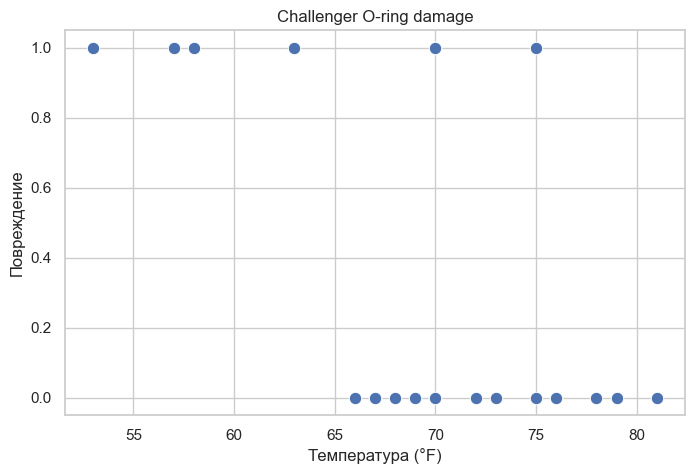

In [7]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="temperature",
    y="damage",
    s=80
)

plt.xlabel("Температура (°F)")
plt.ylabel("Повреждение")

plt.title("Challenger O-ring damage")

plt.show()

In [8]:
x = df["temperature"].values
y = df["damage"].values

x_mean = x.mean()
x_std = x.std()

x_scaled = (x - x_mean) / x_std

In [9]:
with pm.Model() as challenger_model:

    alpha = pm.Normal(
        "alpha",
        mu=0,
        sigma=10
    )

    beta = pm.Normal(
        "beta",
        mu=0,
        sigma=10
    )

    mu = alpha + beta * x_scaled

    p = pm.Deterministic(
        "p",
        pm.math.sigmoid(mu)
    )

    y_obs = pm.Bernoulli(
        "y_obs",
        p=p,
        observed=y
    )

    trace_challenger = pm.sample(
        draws=3000,
        tune=2000,
        target_accept=0.95,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 2_000 tune and 3_000 draw iterations (8_000 + 12_000 draws total) took 1 seconds.


In [10]:
az.summary(
    trace_challenger,
    var_names=["alpha", "beta"]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-1.238,0.631,-2.414,-0.101,0.008,0.007,6282.0,6318.0,1.0
beta,-1.991,0.873,-3.656,-0.500,0.012,0.012,5957.0,5472.0,1.0


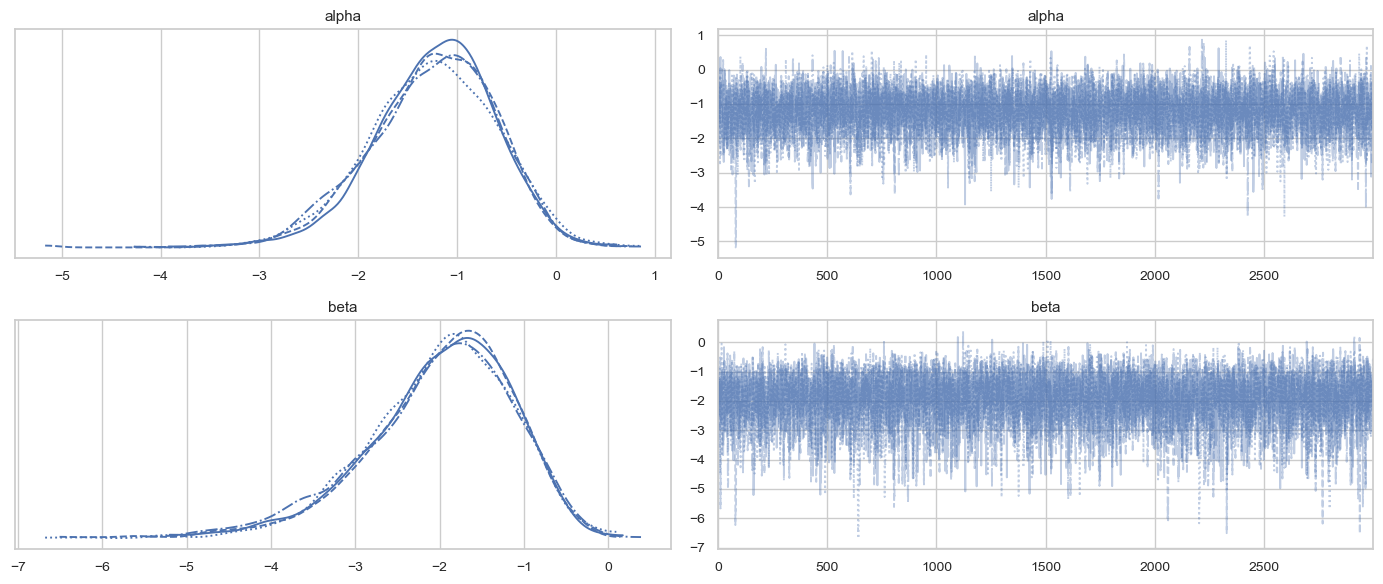

In [11]:
az.plot_trace(
    trace_challenger,
    var_names=["alpha", "beta"],
    figsize=(14, 6)
)

plt.tight_layout()
plt.show()

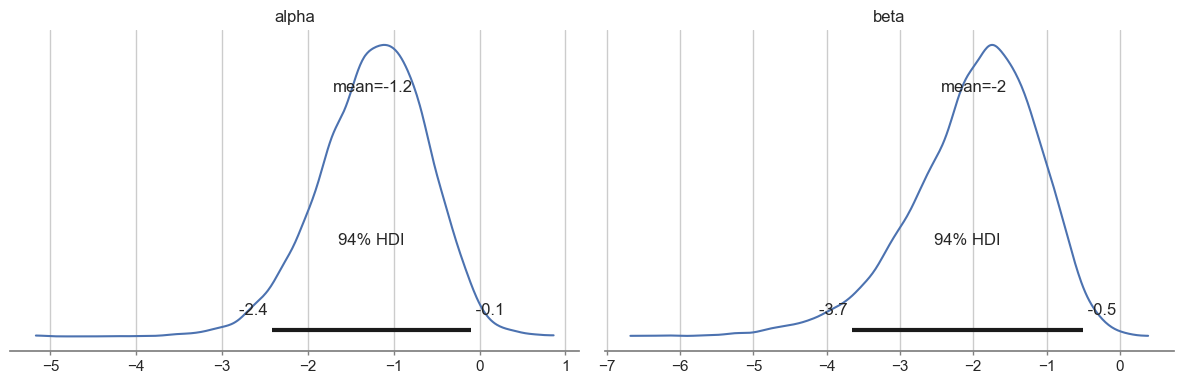

In [12]:
az.plot_posterior(
    trace_challenger,
    var_names=["alpha", "beta"],
    figsize=(12, 4)
)

plt.tight_layout()
plt.show()

In [13]:
posterior = trace_challenger.posterior

alpha_samples = posterior["alpha"].stack(
    sample=("chain", "draw")
).values

beta_samples = posterior["beta"].stack(
    sample=("chain", "draw")
).values

In [14]:
x_grid = np.linspace(
    x_scaled.min(),
    x_scaled.max(),
    200
)

In [15]:
p_lines = 1 / (
    1 + np.exp(
        -(alpha_samples[:, None]
          + beta_samples[:, None] * x_grid[None, :])
    )
)

In [16]:
p_mean = p_lines.mean(axis=0)

p_hdi = az.hdi(
    p_lines,
    hdi_prob=0.94
)

/var/folders/k6/s4whb1m90ybdsx23txzqnfdw0000gn/T/ipykernel_39154/2306248056.py:3: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  p_hdi = az.hdi(


In [17]:
x_grid_original = x_grid * x_std + x_mean

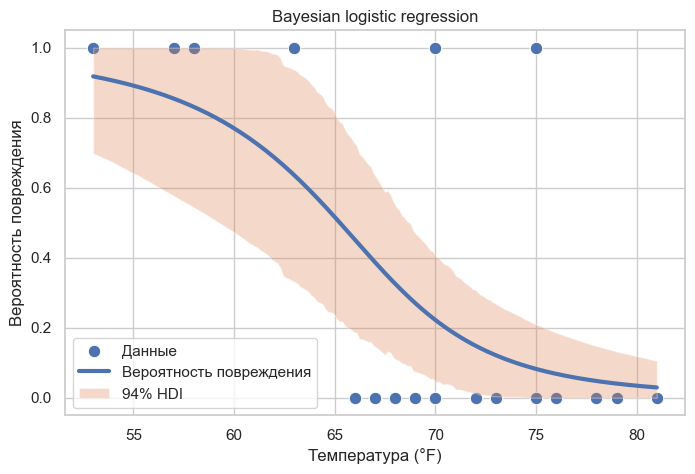

In [18]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=x,
    y=y,
    s=80,
    label="Данные"
)

plt.plot(
    x_grid_original,
    p_mean,
    linewidth=3,
    label="Вероятность повреждения"
)

plt.fill_between(
    x_grid_original,
    p_hdi[:, 0],
    p_hdi[:, 1],
    alpha=0.3,
    label="94% HDI"
)

plt.xlabel("Температура (°F)")
plt.ylabel("Вероятность повреждения")

plt.title("Bayesian logistic regression")

plt.legend()

plt.show()